# Autoencoder + XGBoost
Autoencoder convolucional treinado com perda combinada MSE + SSIM, seguido de classificação com XGBoost.  

Modelo treinado no Kaggle com o GPU T4 x2

## Imports necessários

In [ ]:
!pip install -q xgboost scikit-learn

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

from xgboost import XGBClassifier

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE    = 8
LATENT_DIM    = 2048
EPOCHS        = 50
LEARNING_RATE = 3e-4
IMAGE_SIZE    = 128

print(f'Device: {DEVICE}')


Device: cuda


## Função de Loss combinada: MSE + SSIM

In [5]:
!pip install -q pytorch-msssim

from pytorch_msssim import ssim

def combined_loss(output, target):
    mse_loss = nn.MSELoss()(output, target)
    # desnormaliza de [-1,1] para [0,1] para o SSIM
    out_01   = output * 0.5 + 0.5
    tgt_01   = target * 0.5 + 0.5
    ssim_loss = 1 - ssim(out_01, tgt_01, data_range=1.0, size_average=True)
    return 0.6 * mse_loss + 0.4 * ssim_loss

## Caminhos

In [ ]:
base_dir = '/kaggle/input/datasets/jasminazul/dataset_monica/dataset' 


print('base_dir existe:', os.path.isdir(base_dir))

# Verificar estrutura
for phase in ['train', 'val', 'test']:
    p = os.path.join(base_dir, phase)
    print(f'  {phase}/  existe: {os.path.isdir(p)}')


base_dir existe: True
  train/  existe: True
  val/  existe: True
  test/  existe: True


## Carregar Dataset

In [ ]:
valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
phases     = ['train', 'val', 'test']

# Descobrir classes a partir da pasta train
class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print('Classes:', class_names)

data = {phase: {'images': [], 'labels': []} for phase in phases}
# carregar imagens e respetivas labels
for phase in phases:
    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        if not os.path.isdir(class_dir):
            continue
        files = [
            os.path.join(class_dir, f)
            for f in os.listdir(class_dir)
            if f.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(files)
        data[phase]['labels'].extend([idx] * len(files))
    print(f'{phase.capitalize():6s}: {len(data[phase]["images"])} imagens')


Classes: ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train : 1067 imagens
Val   : 234 imagens
Test  : 267 imagens


## Transforms e DataLoaders

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), #  converte para grayscale (1 canal)
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) 
])

# classe do dataset
class MedicalDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# criar os datasets e os dataloaders
train_ds = MedicalDataset(data['train']['images'], data['train']['labels'], transform)
val_ds   = MedicalDataset(data['val']['images'],   data['val']['labels'],   transform)
test_ds  = MedicalDataset(data['test']['images'],  data['test']['labels'],  transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train: 1067 | Val: 234 | Test: 267


## Autoencoder Convolucional

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, latent_dim)
        )

        self.decoder_fc = nn.Linear(latent_dim, 128 * 16 * 16)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        z   = self.encoder(x)
        out = self.decoder_fc(z)
        out = out.view(-1, 128, 16, 16)
        out = self.decoder(out)
        return out

# instanciar o modelo, a loss combinada, otimizador e scheduler
model     = Autoencoder(latent_dim=LATENT_DIM).to(DEVICE)
criterion = combined_loss
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'Parâmetros: {sum(p.numel() for p in model.parameters()):,}')


Parâmetros: 134,510,305


## Treino do Autoencoder

In [ ]:
best_loss = float('inf')
ae_save   = '/kaggle/working/autoencoder_ercp.pth'

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    # treino do autoencoder
    for images_batch, _ in train_loader:
        images_batch = images_batch.to(DEVICE)
        outputs      = model(images_batch)
        loss         = criterion(outputs, images_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    scheduler.step()

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), ae_save)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.6f}  Best: {best_loss:.6f}')

print(f'\nMelhor loss: {best_loss:.6f}')


Epoch   1/50  Loss: 0.283484  Best: 0.283484
Epoch  10/50  Loss: 0.051517  Best: 0.051517
Epoch  20/50  Loss: 0.025177  Best: 0.025177
Epoch  30/50  Loss: 0.014862  Best: 0.014862
Epoch  40/50  Loss: 0.010257  Best: 0.010257
Epoch  50/50  Loss: 0.009217  Best: 0.009217

Melhor loss: 0.009217


## Verificação Visual das Reconstruções

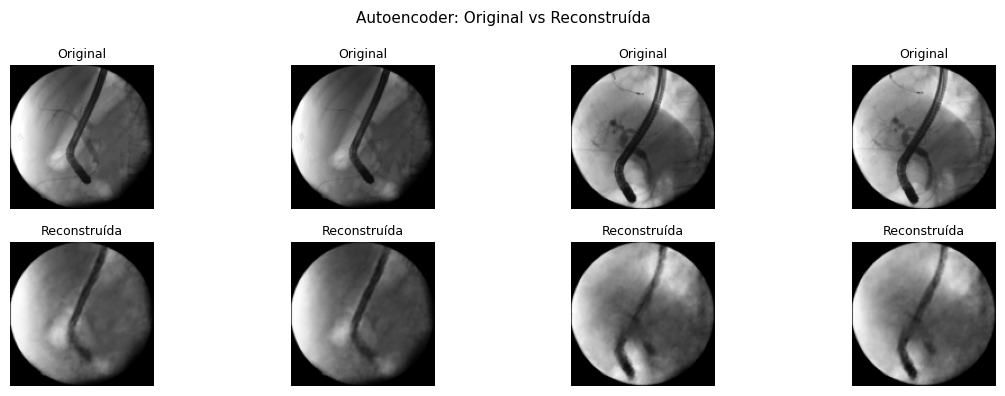

In [ ]:
model.load_state_dict(torch.load(ae_save, map_location=DEVICE))
model.eval()

with torch.no_grad():
    imgs, _ = next(iter(val_loader))
    imgs    = imgs.to(DEVICE)
    recon   = model(imgs)

def denorm(img):
    return img * 0.5 + 0.5

plt.figure(figsize=(12, 4))
for i in range(min(4, len(imgs))):
    plt.subplot(2, 4, i+1)
    plt.imshow(denorm(imgs[i][0].cpu()), cmap='gray')
    plt.title('Original', fontsize=9)
    plt.axis('off')
    plt.subplot(2, 4, i+5)
    plt.imshow(denorm(recon[i][0].cpu()), cmap='gray')
    plt.title('Reconstruída', fontsize=9)
    plt.axis('off')
plt.suptitle('Autoencoder: Original vs Reconstruída', fontsize=11)
plt.tight_layout()
plt.show()

## Extração de Features (Espaço Latente)

In [ ]:
def extract_features(dataloader, model, device):
    model.eval()
    features, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            z    = model.encoder(imgs)
            features.append(z.cpu().numpy())
            all_labels.append(lbls.numpy())
    return np.concatenate(features), np.concatenate(all_labels)

# extrair as features para cada conjunto
print('A extrair features...')
X_train_feat, y_train_feat = extract_features(train_loader, model, DEVICE)
X_val_feat,   y_val_feat   = extract_features(val_loader,   model, DEVICE)
X_test_feat,  y_test_feat  = extract_features(test_loader,  model, DEVICE)

print(f'X_train: {X_train_feat.shape}')
print(f'X_val  : {X_val_feat.shape}')
print(f'X_test : {X_test_feat.shape}')


A extrair features...
X_train: (1067, 2048)
X_val  : (234, 2048)
X_test : (267, 2048)


## XGBoost com Class Weights

In [ ]:
# Class weights calculados
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_feat),
    y=y_train_feat
)

sample_weights = np.array([weights[l] for l in y_train_feat])

print('Class weights:')
for name, w in zip(class_names, weights):
    print(f'  {name}: {w:.4f}')

# criar o xgboost 
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=num_class,
    eval_metric='mlogloss',
    random_state=42
)

print('\nA treinar XGBoost (TRAIN)...')

xgb_model.fit(
    X_train_feat,
    y_train_feat,
    sample_weight=sample_weights,
    eval_set=[(X_val_feat, y_val_feat)],
    verbose=50
)

Class weights:
  Biliary_Leaks: 2.4250
  Lithiasis: 0.5282
  Normal: 1.3541
  Stricture: 1.0461

A treinar XGBoost (TRAIN)...
[0]	validation_0-mlogloss:1.38373
[50]	validation_0-mlogloss:1.29855
[100]	validation_0-mlogloss:1.35208
[149]	validation_0-mlogloss:1.42138


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=4, ...)

## Avaliação Final no test set

Accuracy : 0.4569
F1 Macro : 0.3215

               precision    recall  f1-score   support

Biliary_Leaks     0.7500    0.1765    0.2857        17
    Lithiasis     0.4824    0.7805    0.5963       123
       Normal     0.2000    0.0698    0.1034        43
    Stricture     0.4082    0.2381    0.3008        84

     accuracy                         0.4569       267
    macro avg     0.4601    0.3162    0.3215       267
 weighted avg     0.4306    0.4569    0.4042       267



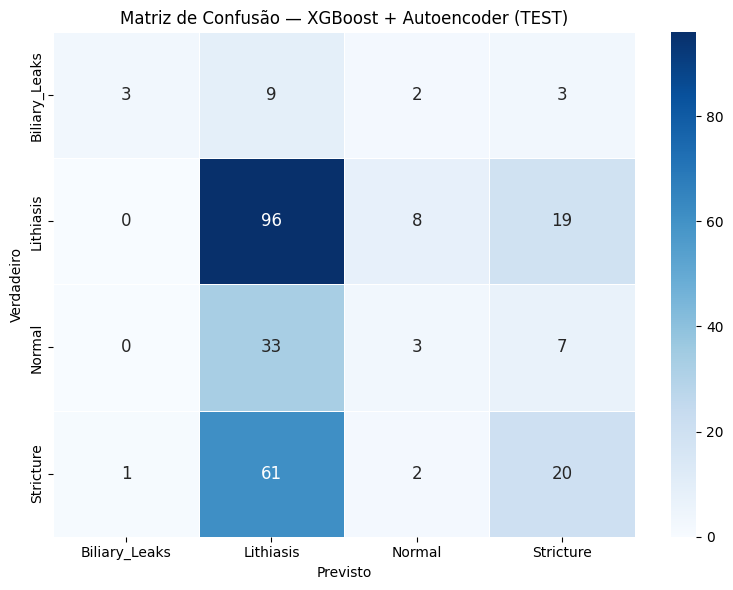

In [ ]:
preds = xgb_model.predict(X_test_feat)  # fazer as previsões

acc = accuracy_score(y_test_feat, preds)
f1  = f1_score(y_test_feat, preds, average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'F1 Macro : {f1:.4f}')
print()

print(classification_report(
    y_test_feat,
    preds,
    target_names=class_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_test_feat, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    linewidths=0.5,
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 12},
    cmap='Blues'
)

plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão — XGBoost + Autoencoder (TEST)')
plt.tight_layout()
plt.savefig('./confusion_matrix_xgb_test.png', dpi=300)
plt.show()